# Assignment - Intelligent Machines, Ethics and Law (COMP2400/6400)

## Name: Mai Tien Dat Tran
## Student Id: 61207314


## Income Prediction and Algorithmic Fairness

In this assignment, you will build an income classification system using the Adult Census Income dataset.

You will manually preprocess the data in Python, handle imbalanced classes, implement machine learning models, and evaluate whether the model behaves differently across demographic subgroups.

This exercise is designed to:

    - Familiarise you with data preprocessing and feature engineering.
    - Expose you to handling class imbalance.
    - Build and evaluate classification models.
    - Critically examine fairness, discrimination, and potential legal/ethical risks in automated decision-making.

This task is graded out of 25 marks and contributes 25 marks toward the final unit assessment.

## Dataset Description

The Adult Census Income dataset contains demographic and employment-related records extracted from census data. The prediction task is to determine whether a person’s annual income is greater than 50K or less than or equal to 50K.

The dataset includes attributes such as:

    age
    workclass
    fnlwgt
    education
    education-num
    marital-status
    occupation
    race
    sex
    capital-gain
    capital-loss
    hours-per-week
    native-country
    income

In this assignment, the target variable is: income.

## Set up
Install libraries if necessary

In [1]:
## import necessary libraries here
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

RANDOM_STATE = 0

## Task 1: Data Loading, Cleaning, and Class Balancing

**(10 marks)**

## TO DO

1. **(1 mark)** Load the dataset:\
   Read the Adult Census Income dataset using pandas.
2. Clean the dataset:
   1. **(1 marks)** The dataset contains missing/invalid values. These need to be handled before modelling. **Drop rows with missing/invalid values in the dataset.**
   2. **(3 marks)** Select key predictors: select a set of **5-8 appropriate predictors (2 marks)** for the income prediction task. Students should decide which variables to include or exclude. **Students should provide a short justification for their choices.(2 marks)** Their explanation should consider both:
predictive relevance, and ethical or fairness concerns.
3. **(4 marks)** Students should **visualise the distribution of the target variable (1 mark)**. They may use a bar chart, count plot, or other suitable visualisation to show the number of records in each income class. Students should then briefly answer:
   1. Based on your visualisation, does the dataset appear to have balanced or imbalanced classes? If you identify a class imbalance problem, **apply an appropriate technique (2 marks)** to address it.
   2. After processing, **visualise the distribution of the target variable using a different plot(1 mark)** to confirm the dataset is now balanced.  
4. **(1 mark)** Split data into training and test dataset. 

In [ ]:
## Q1 Load the dataset

# The CSV file is expected to be in the same folder as this notebook.
df_ori = pd.read_csv("adult_census_income.csv")

df = df_ori.copy()
display(df.head())
display(df.info())
df.describe()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


None

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


I load the dataset with `pandas.read_csv()`. I then inspect it from three angles: `head()` gives a visual preview of the records and confirms the columns loaded correctly; `info()` reports the number of rows and columns, each column's data type, and how many non-null entries it has; and `describe()`  summarises the central tendency and spread of the numeric columns (count, mean, std, min/max, quartiles).

In [3]:
## Q2.A Clean the dataset

# In this dataset, missing or invalid categorical values are represented by '?'.
# Strip whitespace first so that values such as ' ?' are handled correctly.
obj_cols = df.select_dtypes('object').columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

# replace ? with Nan => pandas knows it as missing
df = df.replace('?', np.nan)

print("missing values per column:")
print(df.isna().sum())

# drop rows have any missing value
rows_before = df.shape[0]
df = df.dropna().reset_index(drop=True)
rows_after = df.shape[0]

print(f"\nrows before: {rows_before}")
print(f"rows after:  {rows_after}")
print(f"rows dropped: {rows_before - rows_after}")

missing values per column:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

rows before: 32561
rows after:  30162
rows dropped: 2399


In [4]:
## Q2.B Select key predictors

features = ['age', 'education-num', 'workclass', 'marital-status',
            'occupation', 'hours-per-week', 'capital-gain', 'capital-loss']
target = 'income'

# protected attributes: excluded as predictors, kept aside for the fairness audit
sensitive = ['sex', 'race']

X = df[features].copy()
y = df[target].copy()
sensitive_df = df[sensitive].copy()   # index-aligned with X and y

print('feature matrix:', X.shape)
X.head()

feature matrix: (30162, 8)


,age,education-num,workclass,marital-status,occupation,hours-per-week,capital-gain,capital-loss
0,39,13,State-gov,Never-married,Adm-clerical,40,2174,0
1,50,13,Self-emp-not-inc,Married-civ-spouse,Exec-managerial,13,0,0
2,38,9,Private,Divorced,Handlers-cleaners,40,0,0
3,53,7,Private,Married-civ-spouse,Handlers-cleaners,40,0,0
4,28,13,Private,Married-civ-spouse,Prof-specialty,40,0,0


### Predictor choice justification

I select 8 predictors: `age`, `education-num`, `workclass`, `marital-status`, `occupation`, `hours-per-week`, `capital-gain`, and `capital-loss`. My choices balance two considerations: predictive relevance and fairness.

Predictive relevance (included). These features have a clear, intuitive link to income. `education-num` and `occupation` reflect qualifications and job type; `age` and `hours-per-week` capture career stage and work intensity; `workclass` and `marital-status` carry household and sector effects; and `capital-gain/capital-loss` indicate investment income, one of the strongest signals of higher earnings in this dataset. I keep education-num in its numeric ordinal form so no information is lost in encoding.

Excluded, and why:
- `fnlwgt` : a census sampling weight indicating how many people the record represents in the population. It describes the survey design, not the individual, so it has no predictive meaning for personal income.
- `education`: a text duplicate of `education-num` (the same information). Keeping both introduces redundant, collinear features, so I retain only the numeric version.
- `relationship` : overlaps heavily with marital-status, and its Husband/Wife categories act as a near-direct proxy for sex.
- `native-country` : roughly 90% "United-States", so it adds little discriminative value while functioning as a proxy for nationality/ethnicity.
-  `sex` and `race` : protected attributes. Using them as direct model inputs would permit explicit discrimination on gender and race, which is ethically problematic and, in many decision contexts, legally restricted. I exclude them as predictors but retain them separately to measure fairness later.

Excluding `sex` and `race` achieves only fairness through unawareness. Correlated proxies remain in the data. For example, `marital-status`, and gendered patterns in `occupation` and `hours-per-week`, so the model can still produce disparate outcomes across these groups. This is exactly why I keep the protected attributes aside: not to train on, but to audit whether the model behaves differently across subgroups. I retain `marital-status` for its predictive value while acknowledging its correlation with `sex`, a deliberate trade-off rather than an oversight.

income distribution before balancing:
income
<=50K    22654
>50K      7508
Name: count, dtype: int64


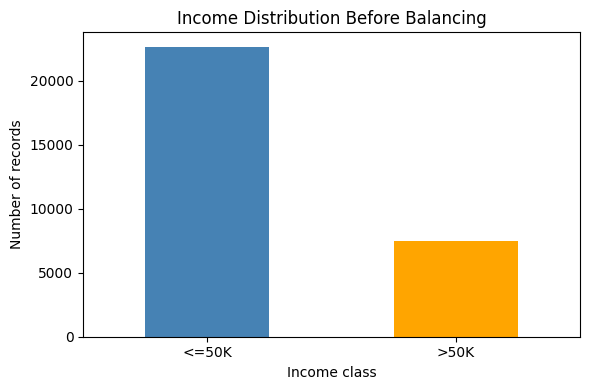

imbalance ratio: 3.02:1


In [5]:
## Q3.A Visualization / imbalance dataset

income_counts = df[target].value_counts()
print('income distribution before balancing:')
print(income_counts)

plt.figure(figsize=(6, 4))
income_counts.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Income Distribution Before Balancing')
plt.xlabel('Income class')
plt.ylabel('Number of records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

imbalance_ratio = income_counts.max() / income_counts.min()
print(f'imbalance ratio: {imbalance_ratio:.2f}:1')   # ~3.0 : 1


income distribution after undersampling:
income
>50K     7508
<=50K    7508
Name: count, dtype: int64


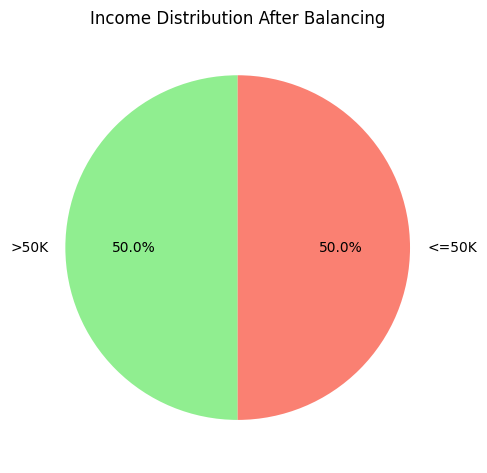

In [6]:
## Q3.B Visualization confirming the data is now balanced

# apply random sampling on the majority class
majority_class = df[df[target] == '<=50K']
minority_class = df[df[target] == '>50K']

majority_under_sampled = majority_class.sample(n=len(minority_class), random_state=RANDOM_STATE)

balanced_df = (
    pd.concat([majority_under_sampled, minority_class], axis=0)
      .sample(frac=1, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)

balanced_counts = balanced_df[target].value_counts()
print('income distribution after undersampling:')
print(balanced_counts)

## Q3.B Confirm with a different plot type (pie)
plt.figure(figsize=(5, 5))
balanced_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90,
                     colors=['lightgreen', 'salmon'])
plt.title('Income Distribution After Balancing')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Imbalance and balancing interpretation

The cleaned dataset is imbalanced: the `<=50K` class has 22,654 records while the `>50K` class has 7,508 records, giving an imbalance ratio of about 3.02:1. If this were left untreated, a classifier could achieve a deceptively high accuracy by favouring the majority class, while performing poorly on the higher-income class.

I used random undersampling of the majority class so that both classes contain 7,508 records. This creates a balanced modelling dataset and makes accuracy, recall, and false positive rates easier to interpret across both income groups. The trade-off is that undersampling discards some majority-class data, so the model may lose some information from the original distribution. I chose this method because it is simple, transparent, and avoids duplicating minority-class records, which could increase overfitting risk.

#### Note on methodology. 
Here I balance the full dataset before splitting, as the task sequence specifies. I'm aware this also re-balances the test set to 50/50,  which no longer reflects the true ~75/25 income distribution and can therefore give optimistic performance estimates. In a production setting the preferred approach is to split first and apply balancing to the training set only, leaving the test set at its natural distribution so that evaluation, and especially the later fairness audit across demographic subgroups remains representative.

In [7]:
## Q4 Split the dataset

train_df, test_df = train_test_split(
    balanced_df,
    test_size=0.2,                     # 80% train / 20% test
    random_state=RANDOM_STATE,
    stratify=balanced_df[target],   
)

# features and target
X_train = train_df[features].copy()
y_train = train_df[target].copy()
X_test  = test_df[features].copy()
y_test  = test_df[target].copy()

# protected attributes for the later fairness audit (kept aligned with the test rows)
sensitive_test = test_df[sensitive].copy()

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('\nTrain class balance:\n', y_train.value_counts(normalize=True).round(3))
print('\nTest class balance:\n',  y_test.value_counts(normalize=True).round(3))

Train: (12012, 8)  Test: (3004, 8)

Train class balance:
 income
>50K     0.5
<=50K    0.5
Name: proportion, dtype: float64

Test class balance:
 income
<=50K    0.5
>50K     0.5
Name: proportion, dtype: float64


## Task 2 (10 points)
TO DO:
1. Data Preprocessing:\
   The selected predictors may include both numerical and categorical features. For example, variables such as age are numerical, while variables such as sex or occupation are categorical.\
   Before training machine learning models, students should apply appropriate preprocessing techniques to prepare the data.

    1. **(2 marks)** Numerical features: Identify the numerical features in your selected predictors and apply an appropriate preprocessing method (for example, scale to zero mean and unit variance). 
    2. **(2 marks)** Categorical features: Identify the categorical features in your selected predictors and apply an appropriate encoding method (for example, use one-hot encoding for categorical features). 

    Students should ensure that all selected predictors are converted into a suitable numeric format before model training.

2. Model training and evaluation:
   1. **(3 marks)** Train a machine learning model for predicting whether a person’s annual income is greater than $50K with a machine learning algorithm discussed during the lectures **(Week 10 to Week 12)** (or any other appropriate algorithm not covered in the lectures). Which machine learning algorithm did you choose, and why? Report accuracy, confusion matrix. 
   2. **(3 marks)** Train an **artificial neural network (Multi-Layered Perceptron Classifier (MLP))** model for recidivism prediction. Report accuracy, and confusion matrix.
  
    Confusion matrix:
  
|                  | **Predicted Positive** | **Predicted Negative** |
|------------------|------------------------|------------------------|
| **Actual Positive** | True Positive (TP)       | False Negative (FN)      |
| **Actual Negative** | False Positive (FP)      | True Negative (TN)       |

In [8]:
## Q1.A Numerical feature preprocessing

numerical_features = ['age', 'education-num', 'hours-per-week',
                      'capital-gain', 'capital-loss']

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_features])
X_test_num  = scaler.transform(X_test[numerical_features])

print('scaled numerical (train):', X_train_num.shape)

scaled numerical (train): (12012, 5)


The numerical features sit on very different scales (`age` in tens, `capital-gain` in the tens of thousands). Standardising to zero mean and unit variance stops large-magnitude features from dominating. The scaler is fit on training data only, so no information from the test set leaks into the scaling.

In [9]:
## Q1.B Categorical feature encoding

categorical_features = ['workclass', 'marital-status', 'occupation']

# one-hot encode (nominal categories => binary columns).
# handle_unknown='ignore' safely handles categories unseen during training.
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat  = encoder.transform(X_test[categorical_features])

print('encoded categorical (train):', X_train_cat.shape)

encoded categorical (train): (12012, 28)


`workclass`, `marital-status`, and `occupation` are nominal, their categories have no natural order. One-hot encoding gives each category its own binary column, so the model doesn't infer a false ordering (as integer/label encoding would). The encoder is fit on training data only, again to avoid leakage.

In [10]:
# combine scaled numerical + encoded categorical features
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed  = np.hstack([X_test_num,  X_test_cat])

# encode the target: <=50K -> 0, >50K -> 1 (>50K is the positive class)
y_train_enc = (y_train == '>50K').astype(int).to_numpy()
y_test_enc  = (y_test  == '>50K').astype(int).to_numpy()

print('final processed train:', X_train_processed.shape)
print('final processed test: ', X_test_processed.shape)

final processed train: (12012, 33)
final processed test:  (3004, 33)


All predictors are now in a fully numeric format: standardised numerical columns horizontally stacked with the one-hot encoded categorical columns, ready for model training.

logistic Regression accuracy: 0.8063
confusion matrix:
 [[1180  322]
 [ 260 1242]]


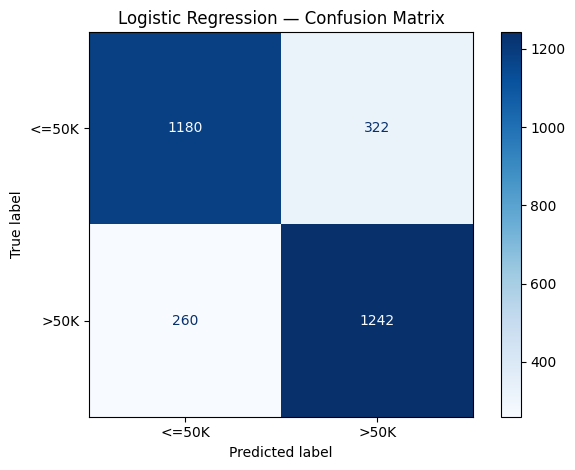

In [11]:
## Q2.A machine learning model

# LogisticRegression model
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_processed, y_train_enc)

y_pred_lr = logreg.predict(X_test_processed)

# accuracy
acc_lr = accuracy_score(y_test_enc, y_pred_lr)
print(f'logistic Regression accuracy: {acc_lr:.4f}')

# confusion matrix
cm_lr = confusion_matrix(y_test_enc, y_pred_lr)
print('confusion matrix:\n', cm_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                              display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

I chose **Logistic Regression**. It is a natural fit for this task for several reasons: (1) it's designed for binary classification, which matches the `<=50K` vs `>50K` target; (2) it's highly **interpretable**, each feature gets a coefficient indicating the direction and strength of its effect on the probability of earning `>50K`, which is valuable in a fairness-sensitive context where we need to understand why the model decides as it does; (3) it works well with our preprocessed inputs (standardised numerics and one-hot encoded categoricals); and (4) it's fast and provides a strong, well-understood baseline against which to compare the neural network. It was also covered in lectures, satisfying the algorithm requirement.

Logistic Regression achieved 80.6% accuracy. The confusion matrix shows balanced performance across both income classes (recall 0.79 for `<=50K`, 0.83 for >50K), with errors split between 322 false positives and 260 false negatives, indicating the model is not biased toward either class, a consequence of training on the balanced dataset.

MLP accuracy: 0.8236
confusion matrix:
 [[1202  300]
 [ 230 1272]]


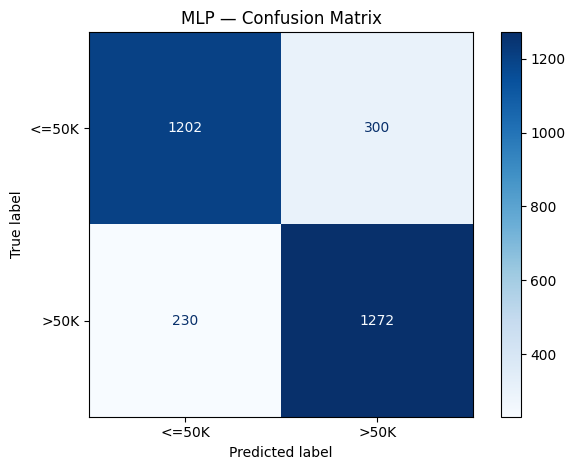

In [12]:
## Q2.B MLP model

## train MLP 
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # two hidden layers
    activation='relu',
    solver='adam',
    max_iter=300,
    early_stopping=True,           # stop when validation score stops improving
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_processed, y_train_enc)

# Predict on the test set
y_pred_mlp = mlp.predict(X_test_processed)

# accuracy
acc_mlp = accuracy_score(y_test_enc, y_pred_mlp)
print(f'MLP accuracy: {acc_mlp:.4f}')

# confusion matrix
cm_mlp = confusion_matrix(y_test_enc, y_pred_mlp)
print('confusion matrix:\n', cm_mlp)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp,
                              display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues', values_format='d')
plt.title('MLP — Confusion Matrix')
plt.tight_layout()
plt.show()

The MLP achieved 82.4% accuracy, slightly outperforming Logistic Regression (80.6%). It reduced both false positives (300 vs 322) and false negatives (230 vs 260), improving recall for high earners from 0.83 to 0.85. The improvement is modest, which suggests the relationship between the predictors and income is largely captured by a linear decision boundary, the  MLP's additional capacity to model non-linear feature interactions yields only a small gain. This makes Logistic Regression a strong, more interpretable baseline, while the MLP offers marginally better predictive performance at the cost of interpretability, a relevant trade-off in a fairness-sensitive application where being able to explain decisions matters.

## Task 3 (5 points)
1. **(1 marks)** For the neural network model, select one appropriate sensitive or socially relevant feature（for example, race, sex, education) and calculate the False Positive Rate (FPR) by the feature.

    Confusion matrix:
  
|                  | **Predicted Positive** | **Predicted Negative** |
|------------------|------------------------|------------------------|
| **Actual Positive** | True Positive (TP)       | False Negative (FN)      |
| **Actual Negative** | False Positive (FP)      | True Negative (TN)       |


False Positive Rate (FPR) tells you how often negative instances (income is <=50K) are incorrectly classified as positive (income is >50K).
Based on the confusion matrix, FPR is calculated as:

<p style="text-align:center;">False Positive Rate (FPR) = FP / (FP + TN)</p>

2. **(4 marks)** Reflect on the disparities you observed in the assignment.
    - Are there any differences in False Positive Rates between the different values of your selected features?
    - Are there potential sources of bias in the data?
    - Describe what steps you would recommend for alleviating such bias in the intended classification model.
    - Discuss the trade-offs and potential impacts of your chosen strategies on overall model performance and fairness.

A false positive is someone who actually earns `<=50K` but the model predicts `>50K`. The FPR is the rate of that error within each group. If one group has a noticeably higher FPR, the model is over-predicting high income for that group relative to the other, a fairness disparity, because the burden of that particular error falls unevenly.

      sex  N (<=50K)   FP   TN     FPR
0    Male        947  258  689  0.2724
1  Female        555   42  513  0.0757


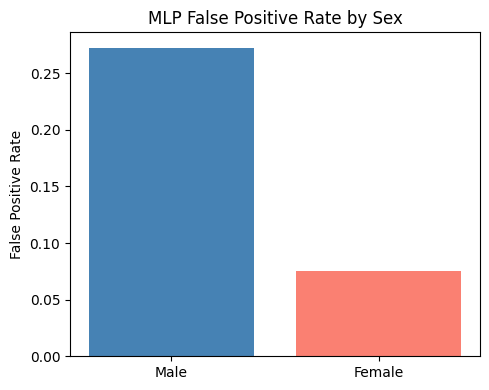

In [13]:
##############################################
# Task 3: Fairness analysis using False Positive Rate (FPR)
# Sensitive feature selected: sex
##############################################

# assemble test-set predictions alongside the protected attributes (all aligned by row order)
audit = sensitive_test.copy()
audit['y_true'] = y_test_enc          # 0 = <=50K, 1 = >50K
audit['y_pred'] = y_pred_mlp          # MLP predictions

def fpr_by_group(data, group_col):
    rows = []
    for group, sub in data.groupby(group_col):
        neg = sub[sub['y_true'] == 0]          # actual negatives (<=50K) only
        fp = int((neg['y_pred'] == 1).sum())   # wrongly predicted >50K
        tn = int((neg['y_pred'] == 0).sum())   # correctly predicted <=50K
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        rows.append({group_col: group, 'N (<=50K)': fp + tn,
                     'FP': fp, 'TN': tn, 'FPR': round(fpr, 4)})
    return pd.DataFrame(rows).sort_values('FPR', ascending=False).reset_index(drop=True)

fpr_sex = fpr_by_group(audit, 'sex')
print(fpr_sex)

plt.figure(figsize=(5, 4))
plt.bar(fpr_sex['sex'], fpr_sex['FPR'], color=['steelblue', 'salmon'])
plt.ylabel('False Positive Rate')
plt.title('MLP False Positive Rate by Sex')
plt.tight_layout()
plt.show()

Male FPR = 0.272, Female FPR = 0.076 => men are roughly 3.6× more likely than women to be falsely classified as earning `>50K`. The model violates the "equal false-positive-rate" criterion badly: of men who actually earn `<=50K`, over a quarter are wrongly flagged as high earners, versus fewer than 1 in 13 women.

In [14]:
def fnr_by_group(data, group_col):
    rows = []
    for group, sub in data.groupby(group_col):
        pos = sub[sub['y_true'] == 1]          # actual positives (>50K) only
        fn = int((pos['y_pred'] == 0).sum())
        tp = int((pos['y_pred'] == 1).sum())
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        rows.append({group_col: group, 'FNR': round(fnr, 4)})
    return pd.DataFrame(rows)

print(fnr_by_group(audit, 'sex'))

      sex     FNR
0  Female  0.2523
1    Male  0.1363


### Expanded fairness and legal/ethical reflection

1. **Differences in FPR and FNR between groups**: The MLP shows a clear gendered disparity in both error types. False-positive rate: 0.272 (Male) vs 0.076 (Female); false-negative rate: 0.136 (Male) vs 0.252 (Female). Men are over-predicted as high earners while high-earning women are missed nearly twice as often. The model violates equalised odds on both components, having effectively learned the association "male → higher income" from the historical data, despite `sex` never being used as a direct input, confirming that proxy features carried the signal.

2. **Potential sources of bias in the data**
- Historical/societal bias. The labels reflect a real 1994 gender income gap — men are genuinely over-represented in the `>50K` class. The model faithfully reproduces this historical inequality; the bias originates in the world the data was collected from, not in a coding mistake.
- Proxy leakage. Although we deliberately excluded sex as a predictor (Task 1), it leaks back in through correlated features: `marital-status`, and gendered patterns in `occupation` and `hours-per-week`. This is exactly the "fairness through unawareness" failure we predicted earlier, now confirmed empirically.
- Representation imbalance. Far fewer high-earning women appear in the data, so the model has a weaker signal for that subgroup.
- Sampling/temporal bias. The data is a 1994 US snapshot, unrepresentative of today; the undersampling we applied also shrank the data and can distort subgroup distributions.

3. **Steps to alleviate the bias**

- **Pre-processing:** Rebalance subgroup representation before training. For example, reweighing methods such as Kamiran and Calders' approach, or subgroup-aware resampling, could help ensure that high-earning women are sufficiently represented in the training data. Proxy features should also be reviewed carefully. Features such as `marital-status`, `occupation`, and `hours-per-week` may carry gendered signals even when `sex` is excluded.

- **In-processing:** Train the model with fairness constraints rather than accuracy alone. For example, an equalised-odds regulariser or fairness-aware optimisation method could penalise large FPR/FNR disparities during training, so the model is discouraged from improving overall accuracy by increasing unequal subgroup error rates.

- **Post-processing:** Adjust decision thresholds separately for groups if necessary to reduce unequal false positive or false negative rates. This kind of post-processing can help equalise error rates after the model has been trained, although it should be used carefully because group-specific thresholds raise legal and ethical concerns.

- **Process-level governance:** Continue auditing the model after training. This should include subgroup performance reporting, model cards documenting known limitations, regular monitoring for drift, and human oversight before any high-stakes use of the system. Affected people should also have a way to contest or seek review of automated decisions.

4. **Trade-offs and impacts**

- **Fairness vs accuracy:** Reducing FPR or FNR disparities may lower overall accuracy because the model is no longer optimising only for the pattern that best fits the historical data. This is not necessarily a weakness; it reflects the fact that fairness is a separate objective from predictive performance.

- **No single perfect fairness metric:** Different fairness definitions, such as equalised odds, demographic parity, and calibration, can be mathematically incompatible when base rates differ between groups. The appropriate fairness goal therefore depends on the decision context and on which type of harm is most serious.

- **Group-specific thresholds are contentious:** Treating groups differently to equalise outcomes can reduce disparate impact, but it can also raise concerns about disparate treatment. Even well-intentioned corrections may create legal or ethical concerns if they explicitly use protected attributes in deployment.

- **Removing proxies can reduce predictive signal:** Features such as `marital-status` and `occupation` are genuinely predictive of income, but they may also act as proxies for gender or other social characteristics. Dropping or transforming them may improve fairness, but it may also reduce model performance.

- **The deepest trade-off:** The underlying problem is not only technical. The dataset reflects historical inequality in income, work, and opportunity. A technically fairer model can reduce some unfair error patterns, but it cannot fully solve the social inequality encoded in the labels. The choice between prioritising false positives or false negatives should depend on the deployment context and who is harmed by each error. For example, if a `>50K` prediction gates access to a financial opportunity, false negatives for high-earning women may deny access to people who should have been eligible.